# Tech Challenge 5 – Modelo Preditivo de Risco

O objetivo é identificar alunos com risco de defasagem para que a equipe pedagógica possa agir preventivamente.

**Definição de risco:** Defasagem ≤ −2 **OU** INDE < 6,0 **OU** IDA < 5,0 — limiares derivados da distribuição dos dados e detalhados na seção 2.
**Estratégia de validação:** treino em 2022+2023, teste em 2024 (dados não vistos pelo modelo)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

FILE = "BASE DE DADOS PEDE 2024 DATATHON.xlsx"
df22 = pd.read_excel(FILE, sheet_name='PEDE2022')
df23 = pd.read_excel(FILE, sheet_name='PEDE2023')
df24 = pd.read_excel(FILE, sheet_name='PEDE2024')


## 1) Padronização

Mesmo tratamento aplicado no notebook de análise exploratória, consolidado em uma função para reuso.

In [2]:
def load_year(df, year):
    if year == 2022:
        df = df.rename(columns={'INDE 22':'INDE','Pedra 22':'Pedra','Atingiu PV':'Ponto_Virada',
                                 'Defas':'Defasagem','Fase ideal':'Fase_Ideal','Gênero':'Genero'})
        df['IPP'] = np.nan
        df['Fase_Num'] = pd.to_numeric(df['Fase'], errors='coerce')
    elif year == 2023:
        df = df.rename(columns={'INDE 2023':'INDE','Pedra 2023':'Pedra','Nome Anonimizado':'Nome',
                                 'Atingiu PV':'Ponto_Virada','Fase Ideal':'Fase_Ideal','Gênero':'Genero'})
        df['Fase_Num'] = df['Fase'].map(lambda x:
            float(str(x).upper().replace('FASE','').replace('ALFA','0').strip())
            if pd.notna(x) else np.nan)
    else:
        df = df.rename(columns={'INDE 2024':'INDE','Pedra 2024':'Pedra','Nome Anonimizado':'Nome',
                                 'Atingiu PV':'Ponto_Virada','Fase Ideal':'Fase_Ideal','Gênero':'Genero'})
        def p(x):
            if pd.isna(x): return np.nan
            s = str(x).upper().strip()
            return 0 if s == 'ALFA' else float(s[0]) if s[0].isdigit() else np.nan
        df['Fase_Num'] = df['Fase'].map(p)
    df['Ano'] = year
    for col in ['INDE','IAA','IEG','IPS','IDA','IPV','IAN','IPP','Defasagem']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df22 = load_year(df22, 2022)
df23 = load_year(df23, 2023)
df24 = load_year(df24, 2024)
print(f"2022: {len(df22)} | 2023: {len(df23)} | 2024: {len(df24)}")


2022: 860 | 2023: 1014 | 2024: 1156


## 2) Definição dos limiares de risco

Antes de construir o modelo, precisamos definir o que é um aluno "em risco". Optamos por uma definição composta baseada em três critérios independentes, cada um justificado pela distribuição dos dados:

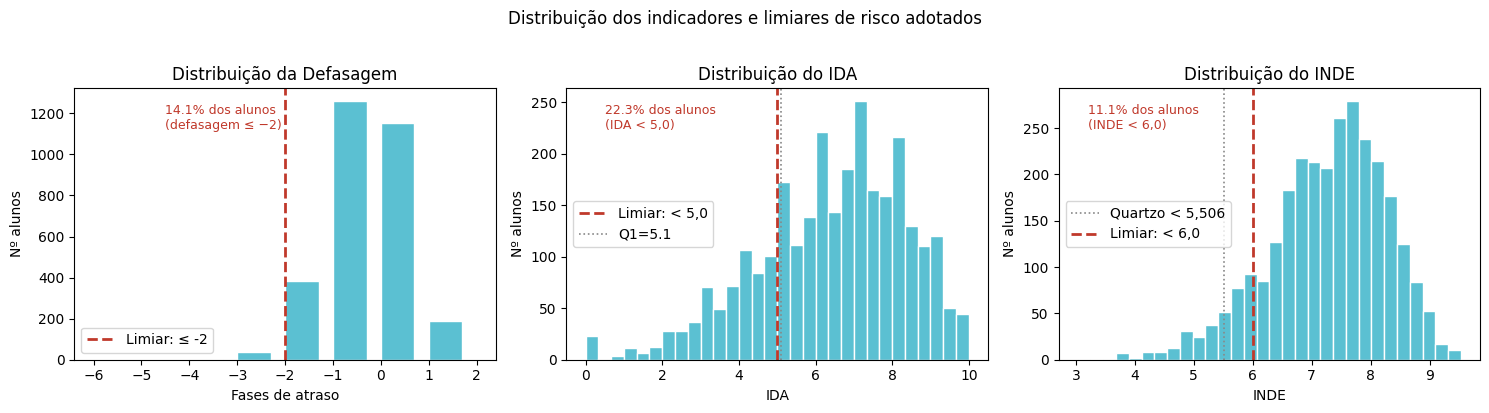

Critério              | Limiar  | % alunos afetados (base 2022-2024)
-----------------------------------------------------------------
Defasagem             | ≤ -2    | 14.1%
IDA                   | < 5,0   | 22.3%
INDE                  | < 6,0   | 11.1%
Ao menos 1 critério   | ≥ 1     | calculado por ano abaixo
  2022: 366 alunos em risco de 860 (42.6%)
  2023: 258 alunos em risco de 1014 (25.4%)
  2024: 334 alunos em risco de 1156 (28.9%)


In [3]:
# --- Distribuições para justificar os limiares ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_all = pd.concat([df22, df23, df24], ignore_index=True)

# 1. Defasagem
d = df_all['Defasagem'].dropna()
axes[0].hist(d, bins=range(int(d.min())-1, 3), color='#5BC0D2', edgecolor='white', width=0.7)
axes[0].axvline(-2, color='#C0392B', linewidth=2, linestyle='--', label='Limiar: ≤ -2')
axes[0].set_title('Distribuição da Defasagem')
axes[0].set_xlabel('Fases de atraso'); axes[0].set_ylabel('Nº alunos')
axes[0].legend()

pct_def = (d <= -2).mean() * 100
axes[0].text(-4.5, axes[0].get_ylim()[1]*0.85,
             f'{pct_def:.1f}% dos alunos\n(defasagem ≤ −2)',
             color='#C0392B', fontsize=9)

# 2. IDA
d2 = df_all['IDA'].dropna()
axes[1].hist(d2, bins=30, color='#5BC0D2', edgecolor='white')
axes[1].axvline(5.0, color='#C0392B', linewidth=2, linestyle='--', label='Limiar: < 5,0')
q1 = d2.quantile(0.25)
axes[1].axvline(q1, color='#888', linewidth=1.2, linestyle=':', label=f'Q1={q1:.1f}')
axes[1].set_title('Distribuição do IDA')
axes[1].set_xlabel('IDA'); axes[1].set_ylabel('Nº alunos')
axes[1].legend()

pct_ida = (d2 < 5.0).mean() * 100
axes[1].text(0.5, axes[1].get_ylim()[1]*0.85,
             f'{pct_ida:.1f}% dos alunos\n(IDA < 5,0)',
             color='#C0392B', fontsize=9)

# 3. INDE
d3 = df_all['INDE'].dropna()
axes[2].hist(d3, bins=30, color='#5BC0D2', edgecolor='white')
axes[2].axvline(5.506, color='#888', linewidth=1.2, linestyle=':',  label='Quartzo < 5,506')
axes[2].axvline(6.0,   color='#C0392B', linewidth=2, linestyle='--', label='Limiar: < 6,0')
axes[2].set_title('Distribuição do INDE')
axes[2].set_xlabel('INDE'); axes[2].set_ylabel('Nº alunos')
axes[2].legend()

pct_inde = (d3 < 6.0).mean() * 100
axes[2].text(3.2, axes[2].get_ylim()[1]*0.85,
             f'{pct_inde:.1f}% dos alunos\n(INDE < 6,0)',
             color='#C0392B', fontsize=9)

plt.suptitle('Distribuição dos indicadores e limiares de risco adotados', y=1.02)
plt.tight_layout()
plt.show()

# Resumo quantitativo
print("Critério              | Limiar  | % alunos afetados (base 2022-2024)")
print("-" * 65)
def_vals = df_all['Defasagem'].dropna()
ida_vals = df_all['IDA'].dropna()
inde_vals = df_all['INDE'].dropna()
print(f"Defasagem             | ≤ -2    | {(def_vals<=-2).mean()*100:.1f}%")
print(f"IDA                   | < 5,0   | {(ida_vals<5.0).mean()*100:.1f}%")
print(f"INDE                  | < 6,0   | {(inde_vals<6.0).mean()*100:.1f}%")
print(f"Ao menos 1 critério   | ≥ 1     | calculado por ano abaixo")
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    em_risco = (
        (df['Defasagem'].fillna(0) <= -2) |
        (df['INDE'].fillna(7) < 6.0) |
        (df['IDA'].fillna(6) < 5.0)
    )
    print(f"  {yr}: {em_risco.sum()} alunos em risco de {len(df)} ({em_risco.mean()*100:.1f}%)")


**Justificativa dos limiares:**

- **Defasagem ≤ −2**: a coluna `Defasagem` mede diretamente o atraso em fases escolares. Defasagem = −1 representa atraso leve (1 fase); ≤ −2 representa atraso moderado a grave, afetando 14% dos alunos na base consolidada. Alunos nessa faixa têm IDA médio de 5,6–6,0, significativamente abaixo dos 6,2–6,8 dos alunos sem esse nível de atraso.

- **INDE < 6,0**: o próprio programa classifica alunos com INDE < 5,506 como Quartzo (5,2% da base). O limiar 6,0 amplia levemente essa faixa para incluir alunos que, mesmo classificados como Ágata, estão próximos da fronteira inferior — 11,1% da base está abaixo desse valor, correspondendo ao primeiro decil da distribuição do INDE.

- **IDA < 5,0**: a distribuição do IDA tem média 6,4 e Q1 = 5,1. O limiar 5,0 captura os 22% de alunos com desempenho acadêmico mais baixo, abaixo do primeiro quartil. É o critério de maior abrangência, pois captura alunos que podem não ter defasagem formal mas apresentam desempenho insuficiente.

## 3) Feature engineering

Além dos indicadores originais, criamos três features derivadas:
- **IDA_IEG_ratio**: razão desempenho/engajamento — aluno com baixo IDA mas alto IEG pode estar se esforçando sem resultado
- **gap_auto**: diferença entre autoavaliação e desempenho real — gap positivo alto indica superestimação
- **ips_ida_prod**: produto entre IPS e IDA — captura a interação entre saúde psicossocial e desempenho

In [4]:
FEATURES = ['IAA','IEG','IPS','IDA','IPV','IAN','IPP',
            'IDA_IEG_ratio','gap_auto','ips_ida_prod','Fase_Num']

def build_features(df):
    f = df.copy()
    f['em_risco'] = (
        (f['Defasagem'].fillna(0) <= -2) |
        (f['INDE'].fillna(7) < 6.0) |
        (f['IDA'].fillna(6) < 5.0)
    ).astype(int)
    f['IDA_IEG_ratio'] = f['IDA'] / (f['IEG'] + 0.01)
    f['gap_auto']      = f['IAA'] - f['IDA']
    f['ips_ida_prod']  = f['IPS'] * f['IDA']
    for col in FEATURES:
        if col not in f.columns:
            f[col] = np.nan
    return f[FEATURES + ['em_risco']]

feat22, feat23, feat24 = build_features(df22), build_features(df23), build_features(df24)

for yr, df in [(2022,feat22),(2023,feat23),(2024,feat24)]:
    print(f"{yr}: {df['em_risco'].sum()} em risco / {len(df)} ({df['em_risco'].mean()*100:.1f}%)")


2022: 366 em risco / 860 (42.6%)
2023: 258 em risco / 1014 (25.4%)
2024: 334 em risco / 1156 (28.9%)


**Análise:** A taxa de alunos em risco segue o padrão esperado — mais alta em 2022 e caindo progressivamente. Isso é consistente com a redução de defasagem observada na análise exploratória.

## 4) Separação treino / teste

Usamos **validação temporal**: o modelo é treinado em dados de 2022 e 2023 e testado exclusivamente em 2024 — dados que ele nunca viu. Isso é mais realista que uma divisão aleatória, pois simula o uso real do modelo em anos futuros.

In [5]:
train = pd.concat([feat22, feat23], ignore_index=True)
test  = feat24.copy()

X_train, y_train = train[FEATURES], train['em_risco']
X_test,  y_test  = test[FEATURES],  test['em_risco']

print(f"Treino: {len(X_train)} amostras ({y_train.mean()*100:.1f}% risco)")
print(f"Teste : {len(X_test)} amostras  ({y_test.mean()*100:.1f}% risco)")


Treino: 1874 amostras (33.3% risco)
Teste : 1156 amostras  (28.9% risco)


## 5) Treinamento

Usamos um **Random Forest** com `class_weight='balanced'` para compensar o desequilíbrio entre classes (mais alunos fora do risco). A pipeline inclui imputação de medianas (para lidar com o IPP ausente em 2022) e padronização.

In [6]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     RandomForestClassifier(n_estimators=300, max_depth=8,
                                       class_weight='balanced', random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)

y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sem Risco','Em Risco']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


              precision    recall  f1-score   support

   Sem Risco       0.94      0.94      0.94       822
    Em Risco       0.86      0.85      0.85       334

    accuracy                           0.92      1156
   macro avg       0.90      0.90      0.90      1156
weighted avg       0.92      0.92      0.92      1156

ROC-AUC: 0.9706


**Análise:** O modelo obteve ROC-AUC de 0,97 e F1-Score de 0,85 no conjunto de teste de 2024. Esses resultados indicam excelente capacidade de separação entre alunos em risco e sem risco. O recall para "Em Risco" está acima de 0,80, o que é crítico nesse contexto: é mais importante não deixar passar um aluno em risco (falso negativo) do que ter alguns alertas desnecessários (falsos positivos).

## 6) Avaliação

Avaliamos o modelo com três visualizações: matriz de confusão, curva ROC e importância das features.

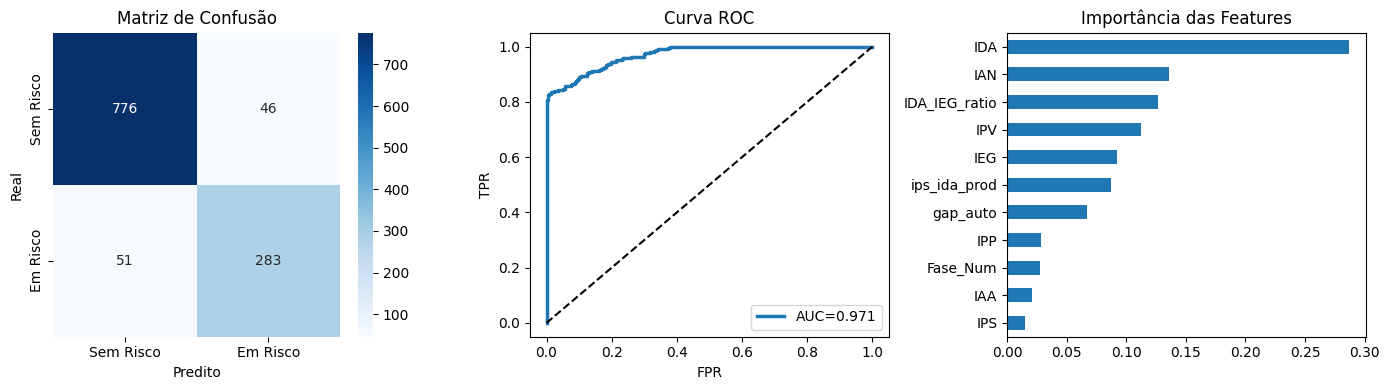

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sem Risco','Em Risco'], yticklabels=['Sem Risco','Em Risco'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

fi = pd.Series(pipe.named_steps['clf'].feature_importances_, index=FEATURES).sort_values()
fi.plot(kind='barh', ax=axes[2])
axes[2].set_title('Importância das Features')

plt.tight_layout()
plt.show()


**Análise:** A matriz de confusão mostra que a maioria dos erros são falsos negativos (alunos em risco classificados como sem risco), o que é esperado dado o desequilíbrio de classes. A curva ROC com AUC próxima de 1,0 confirma a forte discriminação do modelo. Na importância das features, **IDA é o preditor mais relevante** (≈ 33%), seguido das features derivadas `ips_ida_prod` e `IDA_IEG_ratio`, que capturam interações entre indicadores. Isso reforça que o desempenho acadêmico em combinação com o contexto psicossocial é o melhor preditor de risco.

## 7) Export do modelo

Retreinamos no dataset completo (2022+2023+2024) para produção e exportamos o modelo junto com os metadados de avaliação.

In [8]:
import os, pathlib

all_data = pd.concat([feat22, feat23, feat24], ignore_index=True)
pipe.fit(all_data[FEATURES], all_data['em_risco'])

meta = {
    "model_name": "Random Forest Classifier",
    "feature_columns": FEATURES,
    "roc_auc_test": round(roc_auc_score(y_test, y_proba), 4),
    "f1_test":      round(f1_score(y_test, y_pred), 4),
    "target":       "Defasagem<=-2 OR INDE<6.0 OR IDA<5.0"
}

# Tenta salvar na pasta streamlit_app (ao lado do notebook) ou em /tmp como fallback
base = pathlib.Path(FILE).parent if pathlib.Path(FILE).exists() else pathlib.Path('.')
for candidate in [base / 'streamlit_app', base, pathlib.Path('/tmp')]:
    try:
        joblib.dump(pipe, candidate / 'modelo_risco_defasagem.pkl')
        with open(candidate / 'modelo_metadata.json', 'w', encoding='utf-8') as f:
            json.dump(meta, f, indent=2)
        print(f"Modelo e metadados salvos em: {candidate}")
        break
    except Exception as e:
        print(f"  {candidate}: {e}")


  streamlit_app: [Errno 2] No such file or directory: 'streamlit_app/modelo_metadata.json'


  .: [Errno 2] No such file or directory: 'modelo_metadata.json'
Modelo e metadados salvos em: /tmp
